# Population Analysis

In [129]:
import pandas as pd
import numpy as np

## Load dataset from the CSO API

In [130]:
url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/FY006A/CSV/1.0/en"
df = pd.read_csv(url)
df.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


## Prepare data for analysis

### Filter out rows where sex is Both sexes and rows for individual regions

In [131]:
df = df[df['Sex'] != 'Both sexes']
df = df[df['Administrative Counties'] == 'Ireland']
df.head(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
3264,FY006AC01,Population,2022,2022,1,Male,-,All ages,IE0,Ireland,Number,2544549
3296,FY006AC01,Population,2022,2022,1,Male,200,Under 1 year,IE0,Ireland,Number,29610
3328,FY006AC01,Population,2022,2022,1,Male,001,1 year,IE0,Ireland,Number,28875


### Review columns and remove unnecesary ones

In [132]:
headers = df.columns.tolist
headers

<bound method IndexOpsMixin.tolist of Index(['STATISTIC', 'Statistic Label', 'TLIST(A1)', 'CensusYear',
       'C02199V02655', 'Sex', 'C02076V03371', 'Single Year of Age',
       'C03789V04537', 'Administrative Counties', 'UNIT', 'VALUE'],
      dtype='object')>

In [133]:
# Remove columns not required for analysis
drop_col_list = ['STATISTIC', 'Statistic Label','TLIST(A1)','CensusYear','C02199V02655','C02076V03371','C03789V04537','UNIT']
df.drop(columns=drop_col_list, inplace=True)
print (df.head(3))

       Sex Single Year of Age Administrative Counties    VALUE
3264  Male           All ages                 Ireland  2544549
3296  Male       Under 1 year                 Ireland    29610
3328  Male             1 year                 Ireland    28875


### Format Single Year of Age column to contain only digits

In [136]:
# Remove All ages rows
df = df[df["Single Year of Age"] != 'All ages']
print (df.head(3))

# Replace "Under 1 year" with "0"
df["Single Year of Age"] = df["Single Year of Age"].str.replace("Under 1 year","0")

       Sex Single Year of Age Administrative Counties  VALUE
3296  Male                  0                 Ireland  29610
3328  Male                  1                 Ireland  28875
3360  Male                  2                 Ireland  30236


In [137]:
# Replace non-digit characters with an empty string
df["Single Year of Age"] = df["Single Year of Age"].str.replace("\D", "", regex=True)
print (df.head(3))

# Check data by saving to a CSV file
df.to_csv("population_for_analysis.csv")

       Sex Single Year of Age Administrative Counties  VALUE
3296  Male                  0                 Ireland  29610
3328  Male                  1                 Ireland  28875
3360  Male                  2                 Ireland  30236


### Prepare data types for analysis

In [138]:
# Convert the "Single Year of Age" column to integer type for further analysis
df["Single Year of Age"] = df["Single Year of Age"].astype(int)
print (df.head(3))
df.info()

       Sex  Single Year of Age Administrative Counties  VALUE
3296  Male                   0                 Ireland  29610
3328  Male                   1                 Ireland  28875
3360  Male                   2                 Ireland  30236
<class 'pandas.core.frame.DataFrame'>
Index: 202 entries, 3296 to 9760
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Sex                      202 non-null    object
 1   Single Year of Age       202 non-null    int64 
 2   Administrative Counties  202 non-null    object
 3   VALUE                    202 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 7.9+ KB


## Weighted Mean Age By Sex

Per lecture 5 materials, **weighted mean = sum(age * population at that age) / sum(populations at age)**.

Initially, I calculated weighted average for each sex separately using `numpy.average()` ([official documentation](https://numpy.org/devdocs/reference/generated/numpy.average.html)). However, that apprach felt manual. After doing more research, found the following [Python & VBA](https://pythonandvba.com/blog/weighted-average-calculation-in-pandas/) tutorial, which demonstrated a more elegat way to compute weighted averages in Pandas using `groupby.()` function.

In [139]:
# Create a function to calculate weighted average
# The function takes three arguments: values, ages, and sex
def calc_weighted_avg(values, ages, sex):
    # Return calculated of the weighted average 
    # Where population numbers (under ) is used as weights
    return (df['Single Year of Age'] * df['VALUE']).groupby(df['Sex']).sum() / df['VALUE'].groupby(df['Sex']).sum()

# Call the function
calc_weighted_avg(df['VALUE'], df['Single Year of Age'], df['Sex'])

Sex
Female    38.939796
Male      37.739448
dtype: float64

## The Difference Between The Sexes By Age

In [140]:
df_analysis.head(3)

Sex,Female,Male
Single Year of Age,,
0,28186,29610
1,27545,28875
2,28974,30236


In [141]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'Stacked Bar Plot'}, xlabel='Ages', ylabel='Counts'>

<Figure size 640x480 with 0 Axes>

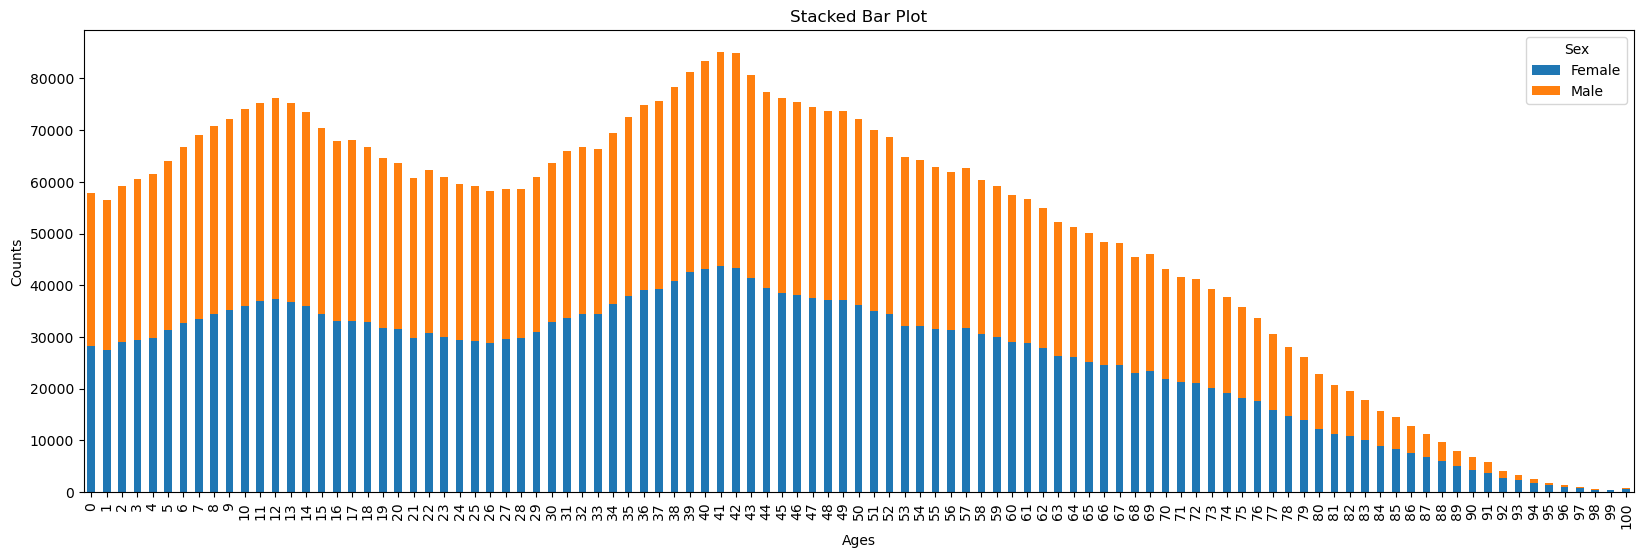

In [142]:
plt.figure()
df_analysis.plot.bar(stacked=True, figsize=(20, 6), title='Stacked Bar Plot', xlabel='Ages', ylabel='Counts')

<Axes: title={'center': 'Stacked Bar Plot'}, xlabel='Values', ylabel='Index'>

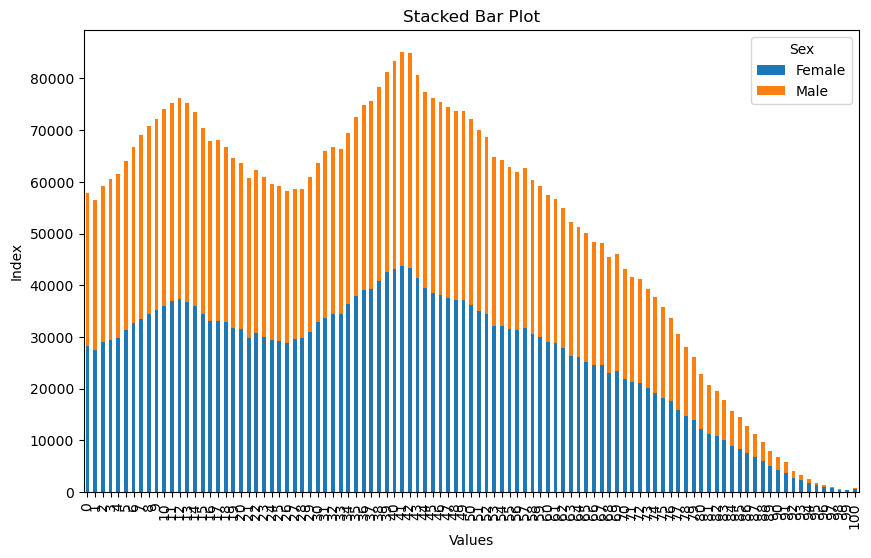

In [143]:
df_analysis.plot.bar(stacked=True, figsize=(10, 6), title='Stacked Bar Plot', ylabel='Index', xlabel='Values')

# DRAFT - 3rd part of the assignment

### Reload data to include individual regions for the 3rd part of the assignment

In [144]:
df = pd.read_csv(url)
df.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7


In [145]:
df = df[df['Sex'] != 'Both sexes']
df.tail(3)

,STATISTIC,Statistic Label,TLIST(A1),CensusYear,C02199V02655,Sex,C02076V03371,Single Year of Age,C03789V04537,Administrative Counties,UNIT,VALUE
9789,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-149d-13a3-e055-000000000001,Cavan County Council,Number,12
9790,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-14a4-13a3-e055-000000000001,Donegal County Council,Number,31
9791,FY006AC01,Population,2022,2022,2,Female,650,100 years and over,2ae19629-1495-13a3-e055-000000000001,Monaghan County Council,Number,7
